In [389]:
#Bibliotecas
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [390]:
caminho_arquivo = "tratados_3det/photon/photon1E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [0, 0, 0, 0, 0, 16, 0, 0, 3, 1, 0, 18, 0, 4, 0, 5, 50, 5, 10, 2, 0, 4, 0, 23, 0, 0, 21, 0, 0, 10, 0, 0, 13, 0, 8, 1, 4, 4, 8, 0, 2, 5, 9, 16, 17, 34, 0, 14, 1, 0, 0, 0, 3, 4, 34, 0, 21, 0, 0, 6, 2, 0, 3, 0, 0, 14, 0, 27, 0, 10, 0, 0, 18, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 11, 0, 23, 2, 12, 4, 124, 0, 0, 35, 9, 0, 10, 0, 0, 2, 2, 1, 19, 28, 17, 0, 0, 0, 7, 0, 17, 0, 1, 0, 3, 0, 4, 7, 29, 35, 6, 20, 51, 0, 12, 3, 0, 19, 14, 31, 2, 0, 0, 0, 0, 0, 1, 92, 0, 0, 2, 1, 0, 0, 0, 26, 0, 0, 10, 7, 0, 18, 27, 0, 0, 0, 0, 0, 13, 4, 23, 0, 5, 2, 2, 24, 26, 0, 15, 0, 0, 1, 3, 0, 4, 72, 1, 9, 16, 0, 0, 0, 12, 0, 10, 2, 10, 0, 0, 181, 36, 0, 5, 5, 0, 1, 32, 8, 0, 8, 7, 0, 12, 1, 89, 0, 0, 10, 0, 0, 8, 2, 13, 0, 19, 16, 3, 0, 46, 0, 2, 0, 0, 23, 11, 0, 1, 5, 0, 6, 2, 5, 3, 6, 0, 7, 15, 1, 55, 0, 0, 0, 9, 39, 0, 0, 0, 0, 0, 6, 5, 34, 0, 2, 13, 0, 11, 0, 37, 4, 0, 0, 4, 0, 0, 0, 14, 4, 9, 13, 2, 13, 0, 0, 10, 0, 0, 1, 2, 0, 24, 9, 0, 82, 0, 0, 0, 15, 0, 0, 0

In [391]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 1E15'

In [392]:
# Posição dos tanques
x1 = [0, 800/np.sqrt(3)]
x2 = [-400, -400/np.sqrt(3)]
x3 = [400, -400/np.sqrt(3)]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1_total = dados_processados['total_por_detector']['TRIG1']
trig2_total = dados_processados['total_por_detector']['TRIG2']
trig3_total = dados_processados['total_por_detector']['TRIG3']

print(trig1_total,'\n',
      trig2_total,'\n',
      trig3_total)

[0, 0, 0, 0, 0, 32, 0, 0, 7, 6, 0, 46, 0, 7, 0, 8, 124, 12, 29, 4, 0, 9, 0, 49, 0, 0, 58, 1, 0, 20, 0, 0, 34, 0, 21, 1, 7, 9, 16, 0, 4, 13, 23, 48, 36, 63, 0, 44, 1, 0, 0, 0, 5, 10, 58, 0, 53, 0, 0, 8, 7, 0, 10, 1, 0, 32, 0, 60, 0, 28, 0, 0, 44, 0, 0, 15, 3, 0, 0, 0, 0, 0, 1, 0, 0, 39, 0, 0, 0, 19, 0, 50, 4, 27, 8, 285, 0, 0, 87, 22, 0, 28, 0, 1, 2, 5, 2, 58, 75, 33, 0, 1, 3, 16, 0, 38, 0, 2, 0, 6, 0, 10, 20, 60, 74, 11, 60, 106, 0, 23, 7, 0, 47, 43, 79, 7, 0, 0, 0, 0, 0, 3, 221, 0, 1, 8, 1, 1, 0, 3, 54, 0, 0, 27, 17, 0, 52, 62, 0, 0, 0, 0, 0, 36, 6, 60, 2, 10, 3, 5, 63, 55, 0, 36, 0, 4, 2, 12, 0, 5, 170, 1, 19, 39, 0, 1, 0, 27, 0, 32, 2, 20, 0, 0, 409, 75, 2, 9, 11, 0, 4, 59, 23, 0, 24, 15, 1, 23, 3, 204, 0, 0, 14, 0, 3, 14, 4, 21, 0, 44, 41, 11, 0, 95, 0, 8, 0, 0, 60, 41, 0, 4, 9, 0, 14, 5, 17, 10, 16, 0, 18, 47, 2, 142, 0, 0, 0, 23, 88, 0, 0, 2, 1, 0, 9, 28, 89, 0, 5, 25, 0, 26, 1, 83, 5, 0, 9, 13, 0, 0, 0, 28, 10, 19, 37, 2, 27, 0, 0, 15, 0, 0, 1, 5, 0, 49, 17, 1, 212, 0, 0, 0, 32,

In [393]:
# Triangulação

triangulacao = [
    (a, b, c) for a, b, c in zip(trig1_total, trig2_total, trig3_total) if a != 0 and b != 0 and c != 0
]

trig1, trig2, trig3 = zip(*triangulacao) if triangulacao else ([], [], [])


print(trig1,'\n',
      trig2,'\n',
      trig3)

(32, 7, 6, 46, 7, 8, 124, 12, 29, 4, 9, 49, 58, 20, 34, 21, 1, 7, 9, 16, 4, 13, 23, 48, 36, 63, 44, 5, 10, 58, 53, 8, 7, 10, 1, 32, 60, 28, 44, 15, 3, 39, 19, 50, 4, 27, 8, 285, 87, 22, 28, 2, 5, 58, 75, 33, 1, 3, 16, 38, 2, 6, 10, 20, 60, 74, 11, 60, 106, 23, 7, 47, 43, 79, 7, 3, 221, 8, 3, 54, 27, 17, 52, 62, 36, 6, 60, 10, 5, 63, 55, 36, 4, 2, 12, 5, 170, 19, 39, 27, 32, 20, 409, 75, 2, 9, 11, 4, 59, 23, 24, 15, 1, 23, 3, 204, 14, 14, 4, 21, 44, 41, 11, 95, 8, 60, 41, 4, 9, 14, 5, 17, 10, 16, 18, 47, 2, 142, 23, 88, 2, 1, 9, 28, 89, 5, 25, 26, 83, 5, 9, 13, 28, 10, 19, 37, 27, 15, 1, 5, 49, 17, 1, 212, 32, 1, 32, 29, 20, 57, 10, 6, 43, 9, 1, 233, 54, 3, 50, 66, 40, 1, 2, 92, 65, 18, 13, 59, 17, 34, 53, 22, 5, 1, 28, 1, 4, 83, 53, 34, 14, 52, 2, 61, 46, 22, 14, 9, 130, 15, 85, 51, 51, 17, 16, 37, 303, 424, 8, 78, 3, 48, 70, 11, 34, 6, 10, 6, 33, 3, 12, 2, 46, 74, 1, 27, 14, 3, 18, 62, 4, 24, 34, 11, 254, 15, 44, 14, 24, 22, 2, 142, 19, 10, 53, 4, 33, 6, 18, 48, 23, 76, 20, 36, 26, 5,

In [394]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [395]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)


df
#df2 = df.mean()
#df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
22.222222,76.980036,32,18,22,80.123362,0.002411,0.001356,0.001657,385.541146,522.576712,487.371382
75.0,72.168784,7,3,6,104.0833,0.000527,0.000226,0.000452,396.862697,563.471383,444.409721
57.142857,-32.991444,6,6,9,65.982888,0.000452,0.000452,0.000678,498.159879,498.159879,395.897327
-33.802817,-6.505355,46,54,42,34.423104,0.003466,0.004068,0.003164,469.60374,429.501263,488.421787
25.0,72.168784,7,4,5,76.376262,0.000527,0.000301,0.000377,390.512484,522.015325,482.182538
…,…,…,…,…,…,…,…,…,…,…,…
0.0,184.752086,6,2,2,184.752086,0.000452,0.000151,0.000151,277.128129,576.888204,576.888204
-53.731343,-3.446867,22,27,18,53.841788,0.001657,0.002034,0.001356,468.418991,414.312873,507.568031
181.818182,-41.98911,6,3,13,186.603689,0.000452,0.000226,0.000979,535.669813,611.731049,288.627416


In [396]:
def calcular_s(rho_i, rho_j, r_i, r_j):
    log_rho_diff = pl.col(rho_i).log() - pl.col(rho_j).log()
    log_r_diff = pl.col(r_i).abs().log() - pl.col(r_j).abs().log()

    s_expr = pl.when((log_rho_diff == 0) & (log_r_diff == 0)) \
              .then(0) \
              .otherwise(-log_rho_diff / log_r_diff)
    
    return s_expr

df = df.with_columns([
    calcular_s("rho1", "rho2", "r1_b", "r2_b").alias("s1"),
    calcular_s("rho2", "rho3", "r2_b", "r3_b").alias("s2"),
    calcular_s("rho1", "rho3", "r1_b", "r3_b").alias("s3"),
])

df = df.with_columns(
    df.select(["s1", "s2", "s3"]).mean_horizontal().alias("s_mean")
)
df

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b,s1,s2,s3,s_mean
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
22.222222,76.980036,32,18,22,80.123362,0.002411,0.001356,0.001657,385.541146,522.576712,487.371382,1.891874,2.87719,1.598668,2.122578
75.0,72.168784,7,3,6,104.0833,0.000527,0.000226,0.000452,396.862697,563.471383,444.409721,2.417217,2.920118,1.362278,2.233204
57.142857,-32.991444,6,6,9,65.982888,0.000452,0.000452,0.000678,498.159879,498.159879,395.897327,0.0,1.764686,1.764686,1.176457
-33.802817,-6.505355,46,54,42,34.423104,0.003466,0.004068,0.003164,469.60374,429.501263,488.421787,1.796263,1.954923,2.315386,2.022191
25.0,72.168784,7,4,5,76.376262,0.000527,0.000301,0.000377,390.512484,522.015325,482.182538,1.928134,2.811286,1.595693,2.111704
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,184.752086,6,2,2,184.752086,0.000452,0.000151,0.000151,277.128129,576.888204,576.888204,1.498444,0.0,1.498444,0.998963
-53.731343,-3.446867,22,27,18,53.841788,0.001657,0.002034,0.001356,468.418991,414.312873,507.568031,1.668498,1.997273,2.500022,2.055264
181.818182,-41.98911,6,3,13,186.603689,0.000452,0.000226,0.000979,535.669813,611.731049,288.627416,5.220474,1.952107,1.250345,2.807642


In [397]:
r0 = 7800

# Função para o ajuste
def model(r, C, s, r0):
    return C * ((r/r0)**s) / (r0**2)

# Função para ajustar e encontrar C
def find_C(row):
    
    rho_values = np.array([row["rho1"], row["rho2"], row["rho3"]])
    r_values = np.array([row["r1_b"], row["r2_b"], row["r3_b"]])
    s = row["s_mean"]
    
    popt, _ = curve_fit(
        lambda r, C: model(r, C, s, r0),  
        r_values,                          
        rho_values,                        
        p0=[10000.0]   # Valor inicial para C
    )
    
    return popt[0]

df = df.with_columns(
    pl.struct(["rho1", "rho2", "rho3", "r1_b", "r2_b", "r3_b", "s_mean"])
    .map_elements(lambda row: find_C(row), return_dtype= float)
    .alias("C_optimized")
)

df = df.with_columns([
    (pl.col("rho1") * r0**2 * pl.col("r1_b")**pl.col("s_mean")).alias("C1"),
    (pl.col("rho2") * r0**2 * pl.col("r2_b")**pl.col("s_mean")).alias("C2"),
    (pl.col("rho3") * r0**2 * pl.col("r3_b")**pl.col("s_mean")).alias("C3")
])

df = df.with_columns(
    ((pl.col("C1") + pl.col("C2") + pl.col("C3")) / 3).alias("C_mean")
)

df

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b,s1,s2,s3,s_mean,C_optimized,C1,C2,C3,C_mean
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
22.222222,76.980036,32,18,22,80.123362,0.002411,0.001356,0.001657,385.541146,522.576712,487.371382,1.891874,2.87719,1.598668,2.122578,3.7873e7,4.5237e10,4.8525e10,5.1148e10,4.8304e10
75.0,72.168784,7,3,6,104.0833,0.000527,0.000226,0.000452,396.862697,563.471383,444.409721,2.417217,2.920118,1.362278,2.233204,1.0142e7,2.0399e10,1.9125e10,2.2512e10,2.0678e10
57.142857,-32.991444,6,6,9,65.982888,0.000452,0.000452,0.000678,498.159879,498.159879,395.897327,0.0,1.764686,1.764686,1.176457,852055.019163,4.0992e7,4.0992e7,4.6925e7,4.2970e7
-33.802817,-6.505355,46,54,42,34.423104,0.003466,0.004068,0.003164,469.60374,429.501263,488.421787,1.796263,1.954923,2.315386,2.022191,6.4057e7,5.3299e10,5.2235e10,5.2689e10,5.2741e10
25.0,72.168784,7,4,5,76.376262,0.000527,0.000301,0.000377,390.512484,522.015325,482.182538,1.928134,2.811286,1.595693,2.111704,8.2840e6,9.5296e9,1.0051e10,1.0625e10,1.0069e10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,184.752086,6,2,2,184.752086,0.000452,0.000151,0.000151,277.128129,576.888204,576.888204,1.498444,0.0,1.498444,0.998963,190718.129616,7.5772e6,5.2538e6,5.2538e6,6.0283e6
-53.731343,-3.446867,22,27,18,53.841788,0.001657,0.002034,0.001356,468.418991,414.312873,507.568031,1.668498,1.997273,2.500022,2.055264,3.1833e7,3.1081e10,2.9640e10,2.9991e10,3.0237e10
181.818182,-41.98911,6,3,13,186.603689,0.000452,0.000226,0.000979,535.669813,611.731049,288.627416,5.220474,1.952107,1.250345,2.807642,3.4061e7,1.2622e12,9.1622e11,4.8184e11,8.8675e11


In [398]:
# Modelagem NKG
#def model(r, C, s):
#    r0 = 7800
#    return C/(r0**2)*(r/r0)**(s-2)*(1+r/r0)**(s-4.5)

def model(r, C, s, r0=7800):
     return C/(r0**2) * (r/r0)**s

parameters = []
uncertainties = []

x_cols = ['r1_b', 'r2_b', 'r3_b']  
y_cols = ['rho1', 'rho2', 'rho3']

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i]  
    rho = y[i]  
    try:
        popt, pcov = curve_fit(model, r, rho, bounds= ([800, -2], [np.inf, 2]))

        perr = np.sqrt(np.diag(pcov))

        parameters.append(popt)
        uncertainties.append(perr)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])


parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    's': [p[1] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    's_err': [e[1] for e in uncertainties]
})

parameters_df


C,s,C_err,s_err
f64,f64,f64,f64
818.888245,-1.724351,469.336552,0.198123
801.369469,-1.215613,2544.899375,1.105158
802.30381,-1.304532,1057.068619,0.460234
1478.520425,-1.763605,788.877715,0.188024
801.735775,-1.210126,1459.710278,0.634783
…,…,…,…
800.596241,-1.037262,1064.60277,0.424485
814.316124,-1.707401,701.91002,0.302227
800.220056,-1.298325,1065.16734,0.424089


In [399]:
print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {parameters_df['C'].mean():.2e} ± {parameters_df['C'].std():.2e}")
print(f"s: Média = {parameters_df['s'].mean():.2f} ± {parameters_df['s'].std():.2f}")


Estatísticas dos parâmetros:
C: Média = 1.15e+03 ± 7.23e+02
s: Média = -1.57 ± 0.34


In [400]:
threshold = 0.5  # Ajuste conforme necessário
filtered_df = parameters_df.filter(
    (parameters_df['C_err'] < threshold * parameters_df['C']) &
    (parameters_df['s_err'] < threshold)
)
filtered_df

C,s,C_err,s_err
f64,f64,f64,f64
2029.377714,-1.980706,494.891417,0.086215
972.587689,-1.649217,249.479865,0.086067
1556.306365,-1.798324,621.37092,0.140658
984.15534,-1.842257,485.135596,0.173863
4630.246168,-1.995722,953.204218,0.072761
…,…,…,…
802.156626,-1.456964,187.197171,0.071658
1699.307294,-1.93959,716.459682,0.148121
987.589697,-1.828616,391.001937,0.139574


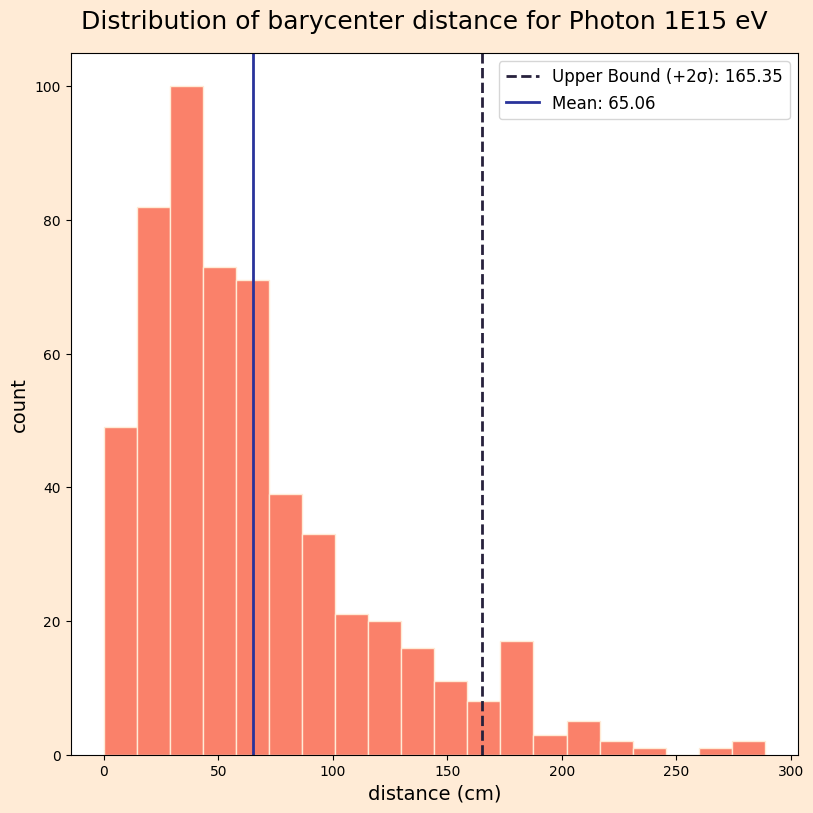

In [401]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

sns.histplot(df, x = df['r_b'], ax = ax, color = '#F95738', edgecolor = '#FFEBD6', bins = 20)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#29339B', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('count', size=14)
ax.legend(loc='upper right', fontsize=12)
#plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

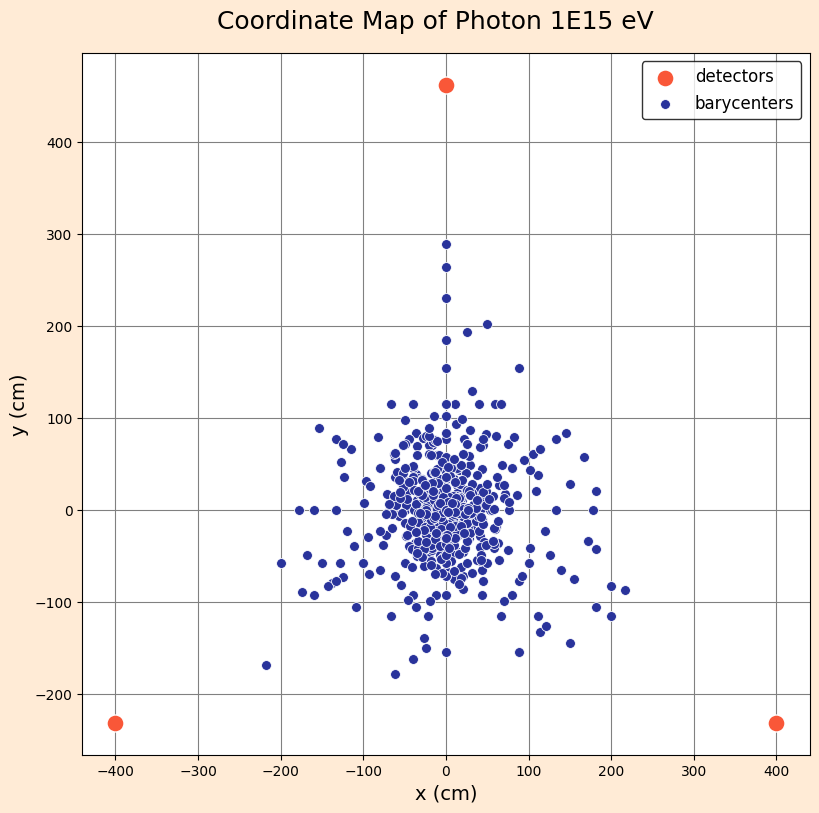

In [402]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#29339B',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/map_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

In [403]:
# Plot dos tanques
#fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
#fig.suptitle('Coordinate Map of Detectors', size = 18)
#fig.tight_layout()
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')
#
#sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
#
#ax.set_xlabel('x (cm)', size = 14)
#ax.set_ylabel('y (cm)', size = 14)
#
#
#ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

[5.97966205e-19 5.85220089e-03]
[1.5469618  2.2275684  2.90902743 3.58963403]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\1404423754.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\1404423754.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.551206,14.0,14.003116,0.022257
2.219846,14.499687,14.494018,0.0391
2.911743,15.0,15.001994,0.013293
3.590396,15.499687,15.500246,0.003609


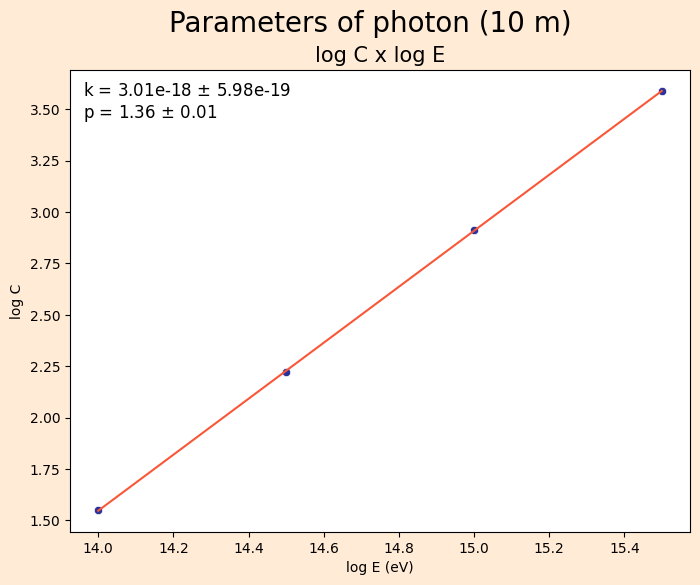

In [404]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [35.58, 165.9, 816.1, 3894]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df_photon = pl.DataFrame(data)

df_photon = df_photon.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df_photon

In [405]:
k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = parameters_df['C'] 
#c_photon = df['C_optimized']
E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
1.0071e15,0.712065,7.1207e12
9.9126e14,0.874314,8.7431e12
9.9211e14,0.789475,7.8948e12
1.5541e15,55.408158,5.5408e14
9.9159e14,0.84105,8.4105e12
…,…,…
9.9055e14,0.944543,9.4454e12
1.0030e15,0.298923,2.9892e12
9.9021e14,0.978717,9.7872e12


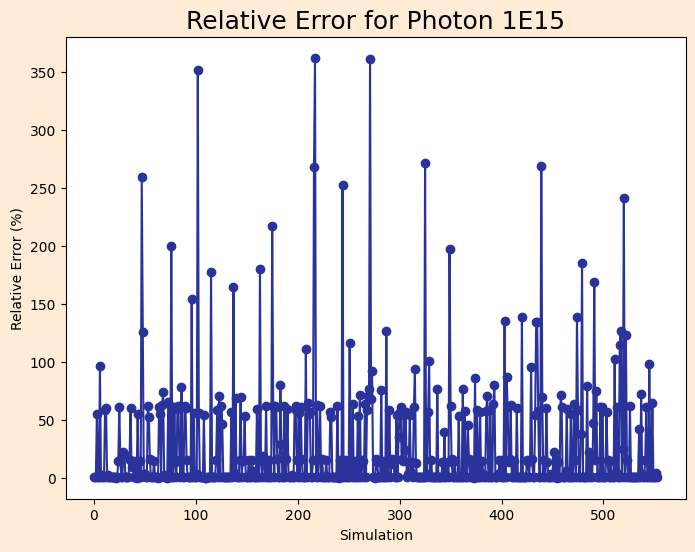

In [406]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
#plt.plot(erro_relativo, marker='o', linestyle='-', color='#29339B')
plt.plot(erro_relativo, marker='o', color='#29339B')
plt.xlabel('Simulation')
plt.ylabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name), size = 18)
#plt.grid(True)
plt.show()

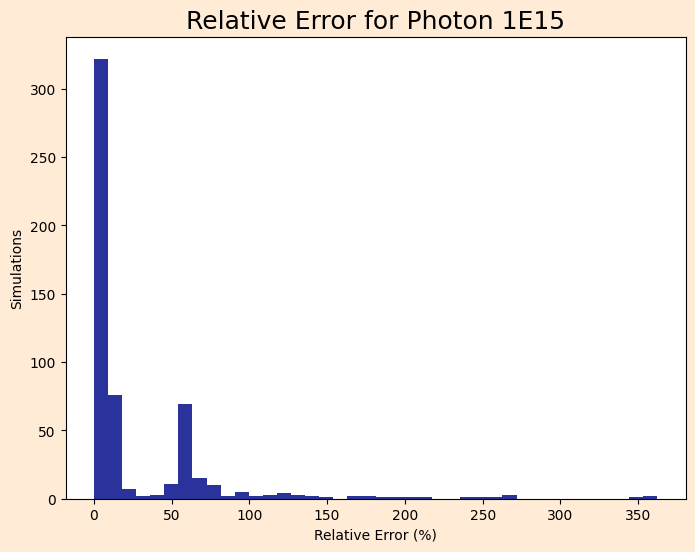

In [407]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40)
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name), size = 18)
#plt.grid(True)
plt.show()

In [408]:
df3.filter(pl.col("Relative_error") < 14)

E,Relative_error,Absolute_error
f64,f64,f64
1.0071e15,0.712065,7.1207e12
9.9126e14,0.874314,8.7431e12
9.9211e14,0.789475,7.8948e12
9.9159e14,0.84105,8.4105e12
9.9203e14,0.796625,7.9662e12
…,…,…
9.9055e14,0.944543,9.4454e12
1.0030e15,0.298923,2.9892e12
9.9021e14,0.978717,9.7872e12


[1.35649802e-13 3.84310014e-03]
[4.62103782 5.21341874 5.8065416 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\1866268954.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\1866268954.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.619928,14.0,13.999064,0.006689
5.215638,14.499687,14.501559,0.012908
5.805433,15.0,14.999065,0.006235


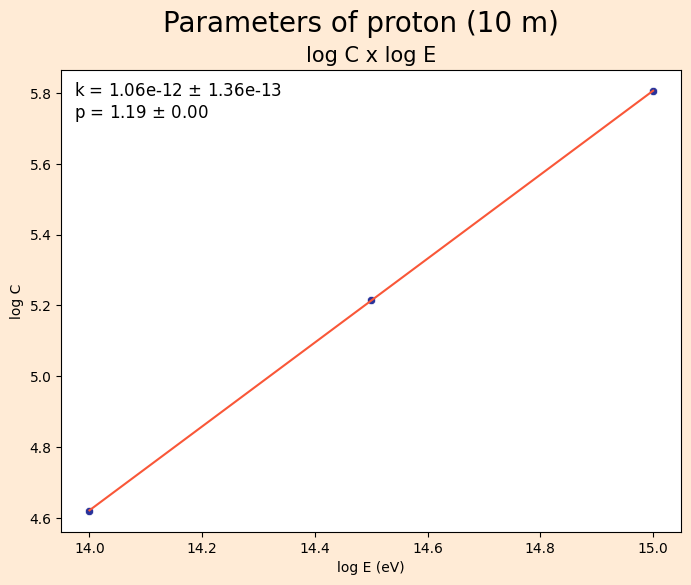

In [409]:
# Fit do próton
from scipy.optimize import curve_fit

C = [4.168e+04, 1.643e+05, 6.389e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.12202004e-06 2.38934361e-01]
[4.27281222 4.66000189 5.04767649]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\492269532.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\492269532.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.34183,14.0,14.089071,0.636221
4.522053,14.499687,14.321657,1.22782
5.116608,15.0,15.088959,0.593061


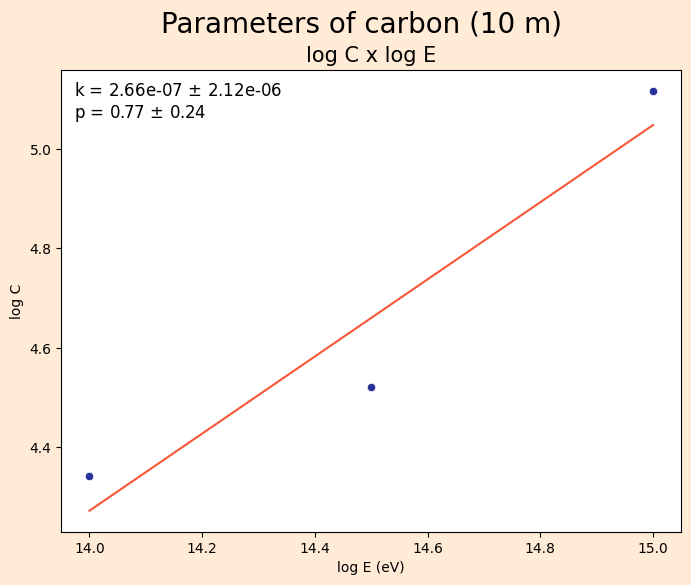

In [410]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [2.197e+04, 3.327e+04, 1.308e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[6.16995911e-16 8.87504152e-02]
[3.71289752 4.40512596 5.09822138]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\4078106409.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\4078106409.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.687261,14.0,13.981494,0.132182
4.456366,14.499687,14.536675,0.255094
5.072617,15.0,14.981518,0.123215


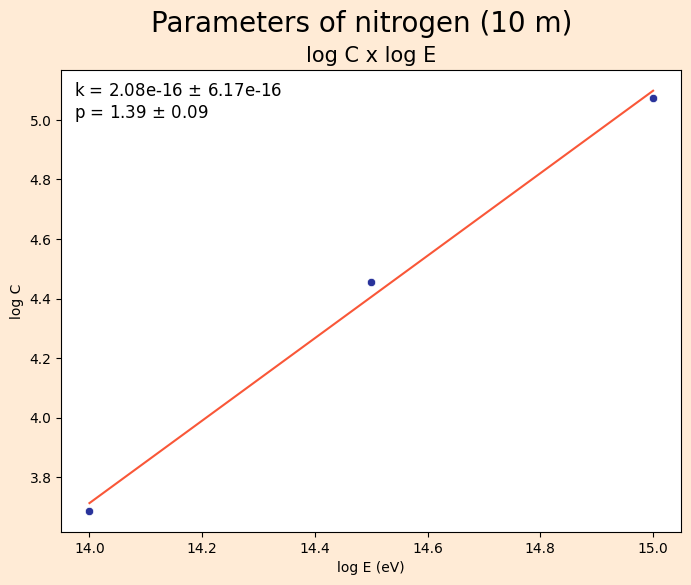

In [411]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [4867, 2.86e+04, 1.182e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\3567477852.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\3567477852.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


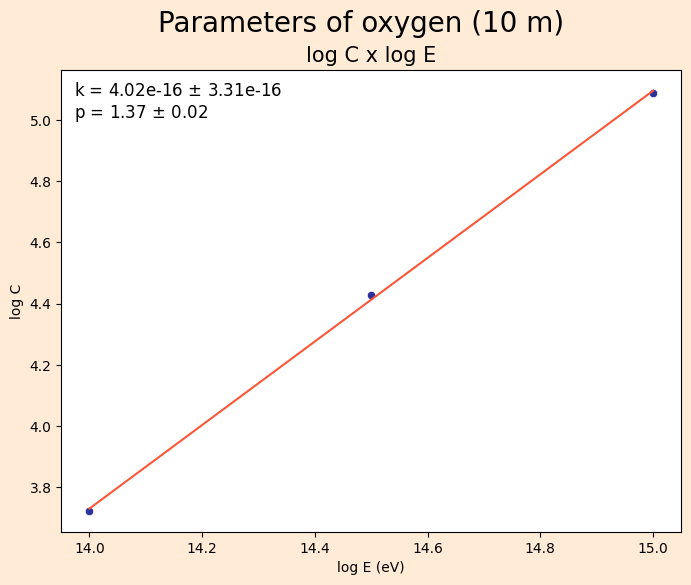

In [412]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\3654635265.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_22880\3654635265.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


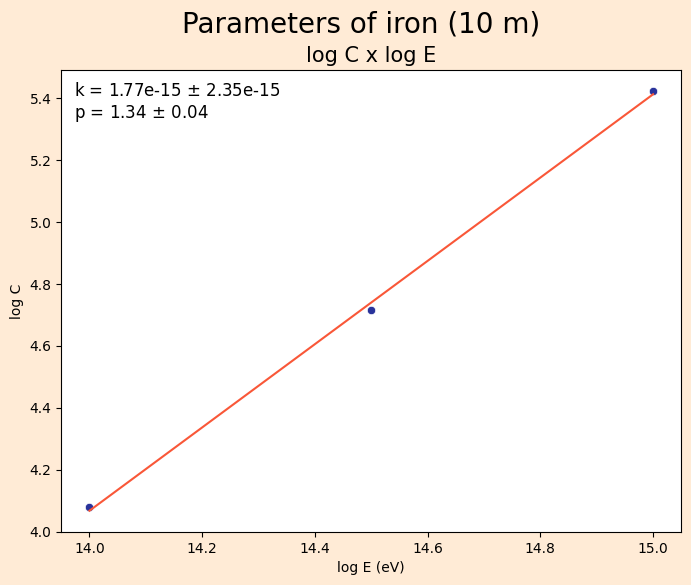

In [413]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [414]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,6.7696e14,2.6581e12,2.1065e11,7.0306e12,6.6489e12,1.3719e12
3.1600e14,2.2253e15,1.0043e13,1.8771e12,2.9232e13,2.4254e13,6.4712e12
1.0000e15,7.6366e15,3.6083e13,2.3525e13,9.5288e13,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

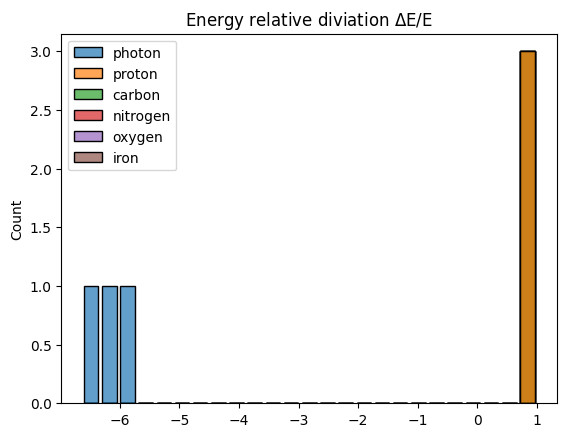

In [415]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_carbon = []
DeltaE_nitrogen = []
DeltaE_oxygen = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_carbon[i])/E_real[i]
    aux4 = (E_real[i] - E_nitrogen[i])/E_real[i]
    aux5 = (E_real[i] - E_oxygen[i])/E_real[i]
    aux6 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_carbon.append(aux3)
    DeltaE_nitrogen.append(aux4)
    DeltaE_oxygen.append(aux5)
    DeltaE_iron.append(aux6)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'carbon':DeltaE_carbon,
    'nitrogen':DeltaE_nitrogen,
    'oxygen':DeltaE_oxygen,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')



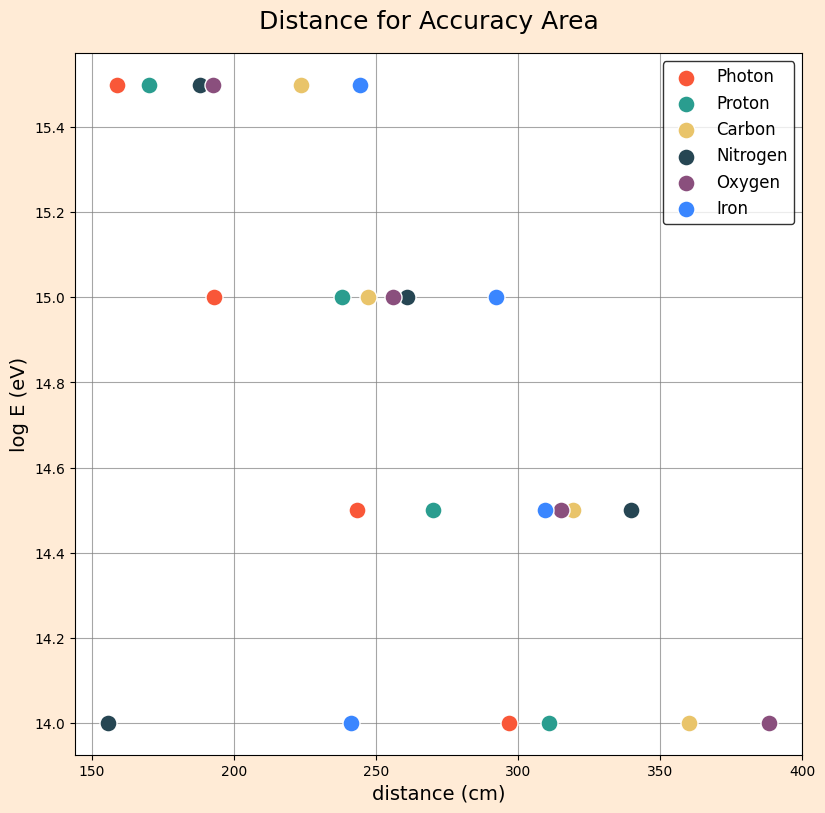

In [416]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(x=photon, y=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(x=proton, y=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(x=carbon, y=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(x=nitrogen, y=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(x=oxygen, y=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(x=iron, y=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('log E (eV)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


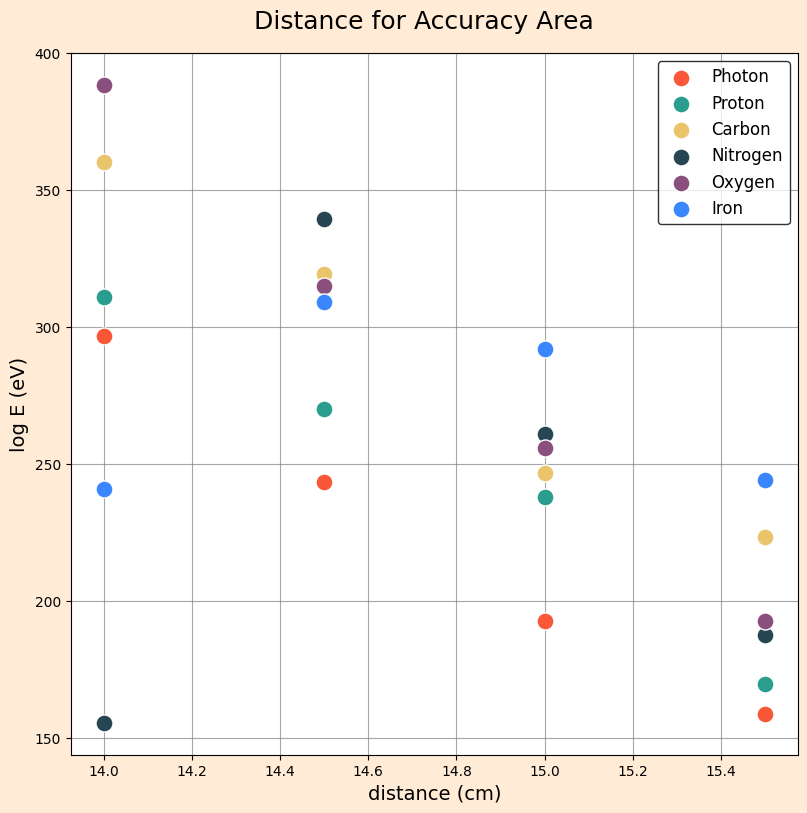

In [417]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(y=photon, x=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(y=proton, x=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(y=carbon, x=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(y=nitrogen, x=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(y=oxygen, x=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(y=iron, x=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('log E (eV)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


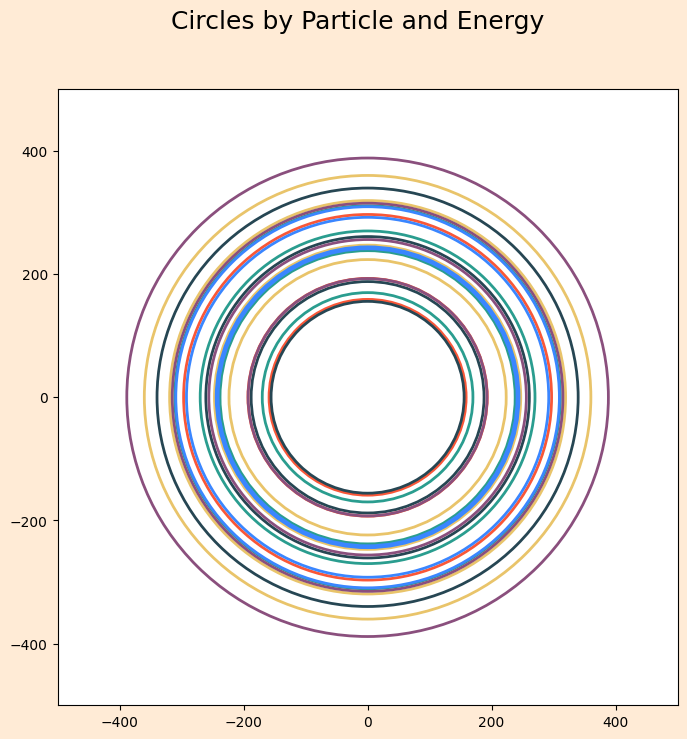

In [418]:
fig, ax = plt.subplots(1,1,figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Circles by Particle and Energy', size=18)

for i, e in enumerate(energy):  
    radius = photon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#F95738', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = proton[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#2A9D8F', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = carbon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#E9C46A', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = nitrogen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#264653', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = oxygen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#8A4F7D', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)


for i, e in enumerate(energy):  
    radius = iron[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#3A86FF', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

plt.xlim([-500,500])
plt.ylim([-500,500])

plt.show()